<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/pytorch_2_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="在 Colab 中打开"/></a>

[查看源码](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/pytorch_2_intro.ipynb)

# 注：PyTorch 2.0 快速教程

In [1]:
import datetime
print(f"Notebook last updated: {datetime.datetime.now()}")

Notebook last updated: 2023-04-14 15:24:37.007274



## 30 秒速览

PyTorch 2.0 已发布！

其中一个最重要的提升是速度。

而且只需一行、并且向后兼容：

```python
torch.compile()
```

换句话说，创建模型后可将其传入 `torch.compile()`，在更新的 GPU（例如 NVIDIA RTX 40 系列、A100、H100）上，训练和推理通常会有明显提速（GPU 越新，提速通常越明显）。

> **注意：** PyTorch 2.0 的升级不止 `torch.compile()`，但它是核心变化之一，因此这里先聚焦它。完整改动请见 [PyTorch 2.0 release notes](https://pytorch.org/blog/pytorch-2.0-release/)。

### 旧版 PyTorch 代码还能运行吗？

可以。PyTorch 2.0 向后兼容，改动主要是增量新增（新特性）。

这意味着如果你已经掌握 PyTorch（例如通过 [learnpytorch.io](https://learnpytorch.io) 课程），可以直接开始使用 PyTorch 2.0；你原有的 PyTorch 代码通常仍可继续运行。

## 快速代码示例

### PyTorch 2.0 之前

In [2]:
import torch
import torchvision

model = torchvision.models.resnet50() # note: this could be any model

### Train model ###

### Test model ###

### PyTorch 2.0 之后

In [3]:
import torch
import torchvision

model = torchvision.models.resnet50() # note: this could be any model
compiled_model = torch.compile(model) # <- magic happens!

### Train model ### <- faster!

### Test model ### <- faster!

## 速度提升

那么，既然 PyTorch 2.0 的重点是速度，它到底快了多少？

PyTorch 团队在 163 个开源模型上进行了测试，覆盖 [Hugging Face Transformers](https://huggingface.co/docs/transformers/index)、[timm](https://github.com/huggingface/pytorch-image-models)（PyTorch Image Models）和 [TorchBench](https://github.com/pytorch/benchmark)（GitHub 上常见项目的精选基准集合）。

这很关键，因为如果 PyTorch 2.0 对大家真实在用的模型没有更快，那它就称不上“更快”。

在混合使用 AMP（自动混合精度，float16）与 float32 精度训练时（更高精度通常需要更多计算），PyTorch 团队发现 `torch.compile()` 在 NVIDIA A100 上训练平均可提速约 43%。

细分来看：timm 约 38%，TorchBench 约 76%，Hugging Face Transformers 约 52%。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/extras-pytorch-2-speedups.png" alt="PyTorch 2.0 在不同模型来源上的速度提升对比" width=650/>

*PyTorch 2.0 在不同模型来源上的加速表现。*来源：*[PyTorch 2.0 announcement post](https://pytorch.org/get-started/pytorch-2.0/)。*

## 3 分钟概览

> **注意：** 以下内容改编自 mrdbourke.com 的 [*A Quick Introduction to PyTorch 2.0*](https://www.mrdbourke.com/pytorch-2/)，并配有对应的 [YouTube 讲解视频](https://youtu.be/WqLKfta5Ijw)。

`torch.compile()` 背后到底发生了什么？

`torch.compile()` 目标是"尽量开箱即用"，其背后有几项关键技术：
* TorchDynamo
* AOTAutograd
* PrimTorch
* TorchInductor

[PyTorch 2.0 getting started notes](https://pytorch.org/get-started/pytorch-2.0/) 对这些有更详细说明。高层看，`torch.compile()` 的两类核心改进是：
* 融合（Fusion，也叫算子融合）
* 图捕获（Graph capture，也叫图追踪）

### Fusion

融合（Fusion），也叫 **算子融合（operator fusion）**，是让深度学习模型“飞起来”的最佳方式之一（brrrrrr 就是模型训练时 GPU 风扇的声音）。

算子融合会把多个操作尽量合并成一个（或者从多次操作合并为更少次）。

为什么？

现代 GPU 的算力非常强，很多时候训练并不是算力受限；真正的主要瓶颈是你能多快把数据从 CPU 送到 GPU。
这通常被称为带宽（bandwidth）或内存带宽（memory bandwidth）。

你希望尽可能降低这部分带宽开销。

并尽可能持续地给“吃数据”的 GPU 喂数据。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/extras-memory-bandwidth-output-small.gif" alt="GPU 与内存之间搬运数据时的带宽开销示意" width=950/>

所以，与其对一份数据执行一次操作后就把结果写回内存（增加带宽开销），不如通过融合把尽可能多的操作串起来一起做。

一个直观类比是用搅拌机做奶昔。

大多数搅拌机都很擅长“搅拌”（就像 GPU 很擅长矩阵乘法）。

如果 **没有算子融合**，就像每加一种食材就启动一次搅拌机。
这不仅低效，还会显著增加带宽开销。

每次真正搅拌都很快（就像 GPU 计算通常很快），但你会把大量时间浪费在一次次加料上。

而 **有算子融合** 时，更像是一开始把食材都放好（operator fusion），然后只搅拌一次。

前面多花一点准备时间，但能把后续损失掉的内存带宽时间基本都省回来。

### 图捕获（Graph capture）

图捕获这个概念，我个人解释得没那么有把握。

但按我的理解，图捕获（graph capture）或图追踪（graph tracing）就是：

* 先梳理出必须发生的一系列操作（例如神经网络中的各层运算）；
* 再把这些即将发生的操作提前捕获/追踪下来。

**没有图捕获** 的计算，像是在陌生区域开车，必须一步步跟着导航转弯。

作为人类司机，你虽然能顺利照着开，但每一次转弯都得思考。

这就类似于 PyTorch 在执行每个操作时，都要先查一下这个操作该怎么做。

比如要做一次加法，它也要先确认“加法怎么做”，然后再执行。

这个过程很快，但依然存在非零开销。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/extras-graph-capture.gif" alt="图捕获示意" width="950"/>

*图捕获示意：先把神经网络中的步骤梳理清楚，再提前捕获每个需要执行的操作。*

**有图捕获** 的计算，则更像在自己熟悉的小区里开车。

你几乎不需要再思考每个转弯。

有时你下车后甚至想不起刚才 5 分钟具体怎么开的。

因为大脑基本在“自动驾驶”状态，额外开销很小。

但前提是你一开始花了些时间记住回家的路线。

这就是图捕获的一个权衡：前期需要一点时间记住要执行的操作，但后续计算通常会更快。

当然，这只是对 `torch.compile()` 背后机制的高层速览（并非完整细节），但这是我当前理解它的方式。

如果你想更深入了解 fusion 和 graph tracing，推荐阅读 Horace He 的 [*Making Deep Learning Go Brrrr From First Principles*](https://horace.io/brrr_intro.html)。

## 需要注意的点

由于 PyTorch 2.0 刚发布不久，部分特性目前仍有一些限制。

其中一个主要限制与模型导出有关。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/extras-pytorch-2-limitations.png" alt="PyTorch 2 的已知限制" width=650/>

*使用 PyTorch 2.0 特性时存在一些限制，例如在 `torch.compile()` 默认配置下目前还不方便导出到移动端。不过这些问题有临时绕过方案，而且导出能力改进已在 PyTorch 2.x 路线图中。*来源：*[PyTorch 2.0 announcement post](https://pytorch.org/get-started/pytorch-2.0/)。*

不过这些问题很可能会在后续版本中逐步修复。

另一个主要限制是：PyTorch 2.0 的很多特性面向较新硬件设计，因此老旧 GPU 或桌面级 GPU（如 NVIDIA RTX 30 系列）的提速通常不如新硬件明显。

## 本节将覆盖什么

由于 PyTorch 2.0 的很多升级都聚焦在速度、且发生在底层（由 PyTorch 自动处理），本 notebook 会做一组对比速度实验。

具体来说，我们会创建两个相同模型：一个使用默认 PyTorch 设置，另一个使用新的 `torch.compile()` 设置，并在同一数据集上训练。

1. 模型 1：不使用 `torch.compile()`。
2. 模型 2：使用 `torch.compile()`。

然后比较两个模型在单次运行与多次运行下的训练/测试耗时。

| **实验** | **模型** | **数据集** | **Epochs** | **Batch size** | **Image size** | **`torch.compile()`** |  
|----- |-----| -----| -----| -----| -----| -----|
| 1（单次运行） | [ResNet50](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet50.html) | [CIFAR10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html#torchvision.datasets.CIFAR10) | 5 | 128 | 224 | 否 |
| 2（单次运行） | ResNet50 | CIFAR10 | 5 | 128 | 224 | 是 |
| 3（多次运行） | ResNet50 | CIFAR10 | 3x5 | 128 | 224 | 否 |
| 4（多次运行） | ResNet50 | CIFAR10 | 3x5 | 128 | 224 | 是 |

这里选择 ResNet50 和 CIFAR10 是因为容易获取、上手快；你也可以替换为自己喜欢的模型/数据集。

根据我的观察，PyTorch 2.0 的最大提速通常出现在 GPU 一次处理尽可能多数据时（例如更大的 batch size/image size/data size/model size）。

> **注意：** 具体 batch size（或 image size）要根据你的 GPU 显存来调整，确保模型能放得下。比如如果你的 GPU 显存为 8GB 或更小，可能需要把 batch size 降到 64 或 32。

## 0. 环境准备

开始前先检查是否安装了 PyTorch 2.x+；如果没有，就先安装。

你可以在 [PyTorch 官方文档](https://pytorch.org/get-started/locally/) 查看如何在本地系统安装 PyTorch 2.x。

> **注意：** 如果你在 Google Colab 上运行，需要先启用 GPU：runtime -> change runtime type -> hardware accelerator。最佳提速通常出现在更新的 NVIDIA/AMD GPU（因为 PyTorch 2.0 会利用较新的硬件能力）上，例如 NVIDIA A100 及以上。本教程聚焦 NVIDIA GPU。

In [4]:
import torch

# 注：Check PyTorch version
pt_version = torch.__version__
print(f"[INFO] Current PyTorch version: {pt_version} (should be 2.x+)")

# 注：Install PyTorch 2.0 if necessary
if pt_version.split(".")[0] == "1": # Check if PyTorch version begins with 1 
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    print("[INFO] PyTorch 2.x installed, if you're on Google Colab, you may need to restart your runtime.\
          Though as of April 2023, Google Colab comes with PyTorch 2.0 pre-installed.")
    import torch
    pt_version = torch.__version__
    print(f"[INFO] Current PyTorch version: {pt_version} (should be 2.x+)")
else:
    print("[INFO] PyTorch 2.x installed, you'll be able to use the new features.")

[INFO] Current PyTorch version: 2.0.0+cu118 (should be 2.x+)
[INFO] PyTorch 2.x installed, you'll be able to use the new features.


太好了！

现在 PyTorch 2.x 已安装完成，让我们开始体验新特性吧！

## 1. 获取 GPU 信息

现在来查看 GPU 信息。

为什么？

PyTorch 2.0 的许多加速效果在较新的 NVIDIA GPU 上最明显（本教程当前聚焦 NVIDIA GPU）。

这是因为 PyTorch 2.0 会利用新一代 GPU 的硬件能力。

那怎样判断是不是“较新”的 GPU 呢？

通常来说，*较新* 的 GPU 计算能力分数（compute capability）会在 8.0 或以上。

你可以在 NVIDIA 开发者页面查看 [NVIDIA GPU compute capability 列表](https://developer.nvidia.com/cuda-gpus)。

下面是一些 2020 年及以后发布的 NVIDIA GPU 分数示例：

| **NVIDIA GPU** | **计算能力分数** | **GPU 类型** | **发布时间** | **架构** |
|----- |-----| -----| -----| -----| 
| RTX 4090 | 8.9 | 桌面级 | 2022 | [Ada Lovelace](https://www.nvidia.com/en-au/geforce/ada-lovelace-architecture/) |
| RTX 4080 | 8.9 | 桌面级 | 2022 | Ada Lovelace |
| RTX 4070 Ti | 8.9 | 桌面级 | 2022 | Ada Lovelace |
| RTX 3090 | 8.6 | 桌面级 | 2020 | [Ampere](https://en.wikipedia.org/wiki/Ampere_(microarchitecture)) |
| RTX 3080 | 8.6 | 桌面级 | 2020 | Ampere| 
| RTX 3070 | 8.6 | 桌面级 | 2020 | Ampere |  
| RTX 3060 Ti | 8.6 | 桌面级 | 2020 | Ampere | 
| H100 | 9.0 | 数据中心级 | 2022 | [Hopper](https://developer.nvidia.com/blog/nvidia-hopper-architecture-in-depth/) | 
| A100 | 8.0 | 数据中心级 | 2020 | Ampere |
| A10 | 8.6 | 数据中心级 | 2021 | Ampere |

计算能力分数在 8.0 及以上的 GPU，通常能看到更明显的加速。

而数据中心级 GPU（如 A100、A10、H100）通常会比桌面级 GPU（如 RTX 3090、RTX 3080、RTX 3070、RTX 3060 Ti）有更显著的提速。

我们可以通过 [`torch.cuda.get_device_capability()`](https://pytorch.org/docs/stable/generated/torch.cuda.get_device_capability.html) 查看当前 GPU 的计算能力分数。

它会返回 `(major, minor)` 形式的元组，比如 A100 对应 `(8, 0)`。

我们还会使用 [`nvidia-smi`](https://developer.nvidia.com/nvidia-system-management-interface) 获取 GPU 名称等其他信息。  

> **资源：** 如果你想深入比较不同 NVIDIA GPU 的速度、成本与取舍，推荐阅读 Tim Dettmers 的博文 [*Which GPU for deep learning?*](https://timdettmers.com/2023/01/30/which-gpu-for-deep-learning/)。

In [5]:
# 注：Make sure we're using a NVIDIA GPU
if torch.cuda.is_available():
  gpu_info = !nvidia-smi
  gpu_info = '\n'.join(gpu_info)
  if gpu_info.find("failed") >= 0:
    print("Not connected to a GPU, to leverage the best of PyTorch 2.0, you should connect to a GPU.")

  # 注：Get GPU name
  gpu_name = !nvidia-smi --query-gpu=gpu_name --format=csv
  gpu_name = gpu_name[1]
  GPU_NAME = gpu_name.replace(" ", "_") # remove underscores for easier saving
  print(f'GPU name: {GPU_NAME}')

  # 注：Get GPU capability score
  GPU_SCORE = torch.cuda.get_device_capability()
  print(f"GPU capability score: {GPU_SCORE}")
  if GPU_SCORE >= (8, 0):
    print(f"GPU score higher than or equal to (8, 0), PyTorch 2.x speedup features available.")
  else:
    print(f"GPU score lower than (8, 0), PyTorch 2.x speedup features will be limited (PyTorch 2.x speedups happen most on newer GPUs).")
  
  # 注：Print GPU info
  print(f"GPU information:\n{gpu_info}")

else:
  print("PyTorch couldn't find a GPU, to leverage the best of PyTorch 2.0, you should connect to a GPU.")

GPU name: NVIDIA_TITAN_RTX
GPU capability score: (7, 5)
GPU score lower than (8, 0), PyTorch 2.x speedup features will be limited (PyTorch 2.x speedups happen most on newer GPUs).
GPU information:
Fri Apr 14 15:24:38 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.89.02    Driver Version: 525.89.02    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA TITAN RTX    Off  | 00000000:01:00.0 Off |                  N/A |
| 40%   50C    P8     9W / 280W |    260MiB / 24576MiB |      0%      Default |
|                               |                  

### 1.1 全局设置设备

PyTorch 2.x 里我很喜欢的一个新特性，是可以通过以下方式设置 [默认设备类型](https://pytorch.org/tutorials/recipes/recipes/changing_default_device.html )：
* 上下文管理器（Context manager）
* 全局设置（Globally）

在这之前，你通常只能通过下面方式显式指定设备：
* `tensor.to(device)`

下面我们看看这两种新设备设置方式的实际效果。

In [6]:
import torch

# 注：Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# 注：Set the device with context manager (requires PyTorch 2.x+)
with torch.device(device):
    # 注：All tensors created in this block will be on device
    layer = torch.nn.Linear(20, 30)
    print(f"Layer weights are on device: {layer.weight.device}")
    print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device: cuda:0


那全局设备设置呢？

这意味着后续创建的张量如果没有显式指定设备，就会默认放到你设定的设备上。

In [7]:
import torch

# 注：Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# 注：Set the device globally
torch.set_default_device(device)

# 注：All tensors created will be on the global device by default
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device: cuda:0


现在切回 CPU。

In [8]:
import torch 

# 注：Set the device globally
torch.set_default_device("cpu")

# 注：All tensors created will be on "cpu"
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cpu
Layer creating data on device: cpu


## 2. 实验设置

好了，开始测速度吧！

为简化对比，我们将按前述方案进行四组实验，统一使用：

* **模型：** ResNet50（来自 [TorchVision](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html)）
* **数据：** CIFAR10（来自 [TorchVision](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html)）
* **Epochs：** 5（单次运行）和 3x5（多次运行）
* **Batch size：** 128
* **Image size：** 224

每组实验都会分别在“使用”和“不使用” `torch.compile()` 两种条件下运行。

为什么同时做单次运行和多次运行？

因为单次运行可以初步看到提速，但我们也需要多次运行取平均值，避免单次结果偶然偏差或异常。

> **注意：** 你可能需要根据 GPU 显存大小下调 batch size 或 image size。本教程以 40GB 显存的 NVIDIA A100 为基准，这类显存容量可以承载更大的 batch size。截止 2023 年 4 月，Google Colab Pro 可用 NVIDIA A100。

下面先导入 `torch` 与 `torchvision`，并设置目标设备。

In [9]:
import torch
import torchvision

print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

# 注：Set the target device
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

PyTorch version: 2.0.0+cu118
TorchVision version: 0.15.1+cu118
Using device: cuda


### 2.1 创建模型与 transforms

下面开始创建模型和 transforms。

这里沿用 [06. PyTorch Transfer Learning section 2.2](https://www.learnpytorch.io/06_pytorch_transfer_learning/) 的同一套思路。

本质上，我们会通过 [`torchvision.models`](https://pytorch.org/vision/stable/models.html) API 同时构建模型与其对应 transforms。

可以通过下面方式获取 ResNet50 的权重与 transforms：
* `model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2`（需要 `torchvision` 0.14 或更高版本）。
* `transforms = model_weights.transforms()`（拿到权重后可获得匹配该模型的 transforms）。

> **注意：** 我们会统计模型参数量，以了解当前模型规模。参数越多，通常需要更多 GPU 显存；但参数更多时，往往也更容易观察到更高的*相对*提速。也就是说，大模型总训练时长可能更久，但由于 GPU 利用更充分，相对加速可能更明显。比如 1000 万参数模型可能只比 100 万参数模型慢约 5 倍，而不是 10 倍。

In [10]:
# 注：Create model weights and transforms
model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 # <- use the latest weights (could also use .DEFAULT)
transforms = model_weights.transforms()

# 注：Setup model
model = torchvision.models.resnet50(weights=model_weights)

# 注：Count the number of parameters in the model 
total_params = sum(
    param.numel() for param in model.parameters() # <- all params
	# param.numel() for param in model.parameters() if param.requires_grad # <- only trainable params
)

print(f"Total parameters of model: {total_params} (the more parameters, the more GPU memory the model will use, the more *relative* of a speedup you'll get)")
print(f"Model transforms:\n{transforms}")

Total parameters of model: 25557032 (the more parameters, the more GPU memory the model will use, the more *relative* of a speedup you'll get)
Model transforms:
ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


我们把上面的流程封装成函数，方便后续复用；同时会调整最后一层（`model.fc`）的输出特征数，使其匹配 CIFAR10 的类别数（10）。

In [11]:
def create_model(num_classes=10):
  """
  Creates a ResNet50 model with the latest weights and transforms via torchvision.
  """
  model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
  transforms = model_weights.transforms()
  model = torchvision.models.resnet50(weights=model_weights)
  
  # 注：Adjust the number of output features in model to match the number of classes in the dataset
  model.fc = torch.nn.Linear(in_features=2048, 
                             out_features=num_classes)
  return model, transforms

model, transforms = create_model()

### 2.2 当 GPU 利用率更高时，提速通常更明显

现代 GPU 执行算子非常快，所以当更多数据实际驻留并参与 GPU 计算时，你通常会看到更明显的*相对*提速。

可以通过以下方式实现：
* **增大 batch size**：每个 batch 的样本更多，意味着 GPU 上同时处理的数据更多，例如 batch size 从 32 提到 256。
* **增大数据规模**：例如图像从 32x32 提到 224x224。数据更大意味着 GPU 上发生更多张量运算。
* **增大模型规模**：例如用 ResNet101 替代 ResNet50。模型更大同样会提升 GPU 上的张量运算量。
* **减少数据搬运**：例如尽量让张量直接驻留在 GPU 显存，减少 CPU 与 GPU 间传输。

这些做法的共同点都是让 GPU 上有*更多*数据。

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/extras-speedups-are-biggest-when-more-gpu-is-used.png" width=950 alt="GPU 使用越充分，相对提速通常越明显"/>

你可能会想："这不意味着 GPU 做了更多工作，反而会更慢吗？"

这个判断在绝对耗时上可能成立，但 GPU 能从 [并行计算](https://en.wikipedia.org/wiki/Parallel_computing) 中受益（大量操作可同时进行）。

也就是说，虽然总体操作更多，GPU 也会尽可能并行地把它们同时完成。

因此，小数据/小模型/小 batch 也可能有提速，但随着规模上升，通常更容易看到*更大的相对提速*。



### 2.3 检查 GPU 的显存上限

为了在更大规模下获得加速，先看看当前 GPU 有多少显存。

如果显存较小，你可能需要下调 batch size 或 image size（可获得的提速空间也会更小）。

我们可以用 [`torch.cuda.mem_get_info()`](https://pytorch.org/docs/stable/generated/torch.cuda.mem_get_info.html#torch.cuda.mem_get_info) 查看显存信息。

它会返回 `(total_free_gpu_memory, total_gpu_memory)` 元组。

其中：
* `total_free_gpu_memory` 表示当前 GPU 上*未被使用*的显存（字节）。
* `total_gpu_memory` 表示 GPU 总显存（字节）。


In [12]:
# 注：Check available GPU memory and total GPU memory 
total_free_gpu_memory, total_gpu_memory = torch.cuda.mem_get_info()
print(f"Total free GPU memory: {round(total_free_gpu_memory * 1e-9, 3)} GB")
print(f"Total GPU memory: {round(total_gpu_memory * 1e-9, 3)} GB")

Total free GPU memory: 24.187 GB
Total GPU memory: 25.386 GB


太好了！

这里的核心结论是：
1. 你可用的 GPU 显存越高，**batch size 可以更大、模型可以更大、样本也可以更大**。
2. 若目标是提速，应尽量让 **GPU 利用率尽可能高**。

下面写一段代码：当可用显存更大时自动使用更大的 batch size。

> **注意：** 理想 batch size 取决于你使用的 GPU、数据集和模型。下面代码以 Google Colab Pro 的 A100 为参考，你可以按自己的 GPU 调整；如果 batch size 设得过高，可能会触发 CUDA out of memory。

如果 GPU 总显存 **大于 16GB**，我们使用 batch size=128、image size=224（显存更大时还可继续增大）。

如果 GPU 总显存 **小于 16GB**，我们使用 batch size=32、image size=64（显存较小场景可按需调整）。

In [13]:
# 注：Set batch size depending on amount of GPU memory
total_free_gpu_memory_gb = round(total_free_gpu_memory * 1e-9, 3)
if total_free_gpu_memory_gb >= 16:
  BATCH_SIZE = 128 # Note: you could experiment with higher values here if you like.
  IMAGE_SIZE = 224
  print(f"GPU memory available is {total_free_gpu_memory_gb} GB, using batch size of {BATCH_SIZE} and image size {IMAGE_SIZE}")
else:
  BATCH_SIZE = 32
  IMAGE_SIZE = 128
  print(f"GPU memory available is {total_free_gpu_memory_gb} GB, using batch size of {BATCH_SIZE} and image size {IMAGE_SIZE}")

GPU memory available is 24.187 GB, using batch size of 128 and image size 224


现在把 `transforms` 调整为对应的 `IMAGE_SIZE`。

In [14]:
transforms.crop_size = IMAGE_SIZE
transforms.resize_size = IMAGE_SIZE 
print(f"Updated data transforms:\n{transforms}")

Updated data transforms:
ImageClassification(
    crop_size=224
    resize_size=224
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 2.4 通过 TF32 获得额外提速潜力

TF32 指 TensorFloat-32，是一种结合 16 位与 32 位浮点特性的计算格式。

其原理可参考 [NVIDIA 博文](https://blogs.nvidia.com/blog/2020/05/14/tensorfloat-32-precision-format/)。

你需要知道的重点是：在 Ampere 及以上架构 GPU（计算能力 8.0+）上，它可帮助你**更快执行矩阵乘法**。

虽然这并非 PyTorch 2.0 独有特性，但既然本节讨论的是新 GPU，这里一并说明。

如果你的 GPU 计算能力在 8.0 或以上，可以设置 [`torch.backends.cuda.matmul.allow_tf32 = True`](https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices) 来启用 TF32（默认是 `False`）。

我们写一个自动判断逻辑：根据 GPU 计算能力分数自动启用或关闭。

> **注意：** 在 PyTorch 1.12+ 中，TensorFloat32 默认关闭（`False`），因为它在某些场景下[可能导致不同设备间结果不完全一致](https://dev-discuss.pytorch.org/t/pytorch-and-tensorfloat32/504)。虽然并非所有任务都会受影响，但值得提前了解。

In [15]:
if GPU_SCORE >= (8, 0):
  print(f"[INFO] Using GPU with score: {GPU_SCORE}, enabling TensorFloat32 (TF32) computing (faster on new GPUs)")
  torch.backends.cuda.matmul.allow_tf32 = True
else:
  print(f"[INFO] Using GPU with score: {GPU_SCORE}, TensorFloat32 (TF32) not available, to use it you need a GPU with score >= (8, 0)")
  torch.backends.cuda.matmul.allow_tf32 = False

[INFO] Using GPU with score: (7, 5), TensorFloat32 (TF32) not available, to use it you need a GPU with score >= (8, 0)


### 2.5 准备数据集

计算侧配置完成！

接下来创建数据集。

为简化实验，我们使用 `torchvision` 中可直接获取的 [CIFAR10](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html)。

关于 CIFAR10，可参考 [CIFAR10 官网](https://www.cs.toronto.edu/~kriz/cifar.html)：

* CIFAR10 含 60,000 张 32x32 彩色图像，共 10 个类别，每类 6,000 张。
* 训练集 50,000 张，测试集 10,000 张。
* 10 个类别分别是：airplane、automobile、bird、cat、deer、dog、frog、horse、ship、truck。

尽管原始图像是 32x32，我们会用前面创建的 `transforms` 将其 resize 到 224x224（更大图像包含更多信息，也会占用更多 GPU 显存）。

In [16]:
# 注：Create train and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='.', 
                                             train=True, 
                                             download=True, 
                                             transform=transforms)

test_dataset = torchvision.datasets.CIFAR10(root='.', 
                                            train=False, # want the test split
                                            download=True, 
                                            transform=transforms)

# 注：Get the lengths of the datasets
train_len = len(train_dataset)
test_len = len(test_dataset)

print(f"[INFO] Train dataset length: {train_len}")
print(f"[INFO] Test dataset length: {test_len}")

Files already downloaded and verified
Files already downloaded and verified
[INFO] Train dataset length: 50000
[INFO] Test dataset length: 10000


### 2.6 创建 DataLoaders

通常在机器学习流程里，GPU 本身并不总是瓶颈。

更常见的瓶颈是数据加载。

也就是从 CPU 把数据搬运到 GPU 的速度。

正如前面讨论过的，我们希望尽可能快地把数据送到 GPU。

下面用 `torch.utils.data.DataLoader` 创建 `DataLoaders`。

`batch_size` 使用前面设定的 `BATCH_SIZE`。

`num_workers` 则设置为 `os.cpu_count()` 返回的 CPU 核心数。

> **注意：** `num_workers` 建议按你的 GPU/CPU 组合多试几个值。在我的经验里通常越大越好，但也有人发现它在 [这个经验上限](https://discuss.pytorch.org/t/guidelines-for-assigning-num-workers-to-dataloader/813/3) 附近趋于饱和：`4 * number_of_gpus_you_have`，例如 1 块 GPU 时 `num_workers = 4 * 1`。

In [17]:
from torch.utils.data import DataLoader

# 注：Create DataLoaders
import os
NUM_WORKERS = os.cpu_count() # <- use all available CPU cores (this number can be tweaked through experimentation but generally more workers means faster dataloading from CPU to GPU)

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS)

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=False,
                              num_workers=NUM_WORKERS)

# 注：Print details
print(f"Train dataloader length: {len(train_dataloader)} batches of size {BATCH_SIZE}")
print(f"Test dataloader length: {len(test_dataloader)} batches of size {BATCH_SIZE}")
print(f"Using number of workers: {NUM_WORKERS} (generally more workers means faster dataloading from CPU to GPU)")

Train dataloader length: 391 batches of size 128
Test dataloader length: 79 batches of size 128
Using number of workers: 16 (generally more workers means faster dataloading from CPU to GPU)


### 2.7 创建训练与测试循环

Dataloaders 已就绪！

接下来创建训练循环和测试循环。

整体结构与 [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/) 中的实现一致，只做少量改动。

由于本节重点是测速度，我们会在每个循环中加入计时逻辑，记录每轮训练/测试耗时。

具体做法是用 Python 的 [`time.time()`](https://docs.python.org/3/library/time.html#time.time) 记录每个 epoch 的开始与结束时间，并写入字典追踪。

> **注意：** 我在实验 PyTorch 2.0 时发现，测试循环里使用 [`torch.inference_mode()`](https://pytorch.org/docs/stable/generated/torch.inference_mode.html) 可能报错，因此这里改用 [`torch.no_grad()`](https://pytorch.org/docs/stable/generated/torch.no_grad.html)。两者功能相近，但 `torch.no_grad()` 是更早的方法。如果你本地 `torch.inference_mode()` 可正常使用，欢迎在 [GitHub discussions](https://github.com/mrdbourke/pytorch-deep-learning/discussions) 告诉我，我会更新本 notebook。

In [18]:
import time
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(epoch: int,
               model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               disable_progress_bar: bool = False) -> Tuple[float, float]:
  """Trains a PyTorch model for a single epoch.

  Turns a target PyTorch model to training mode and then
  runs through all of the required training steps (forward
  pass, loss calculation, optimizer step).

  Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
  """
  # 注：Put model in train mode
  model.train()

  # 注：Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # 注：Loop through data loader data batches
  progress_bar = tqdm(
        enumerate(dataloader), 
        desc=f"Training Epoch {epoch}", 
        total=len(dataloader),
        disable=disable_progress_bar
    )

  for batch, (X, y) in progress_bar:
      # 注：Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate  and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item() 

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # 注：Calculate and accumulate accuracy metrics across all batches
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

      # 注：Update progress bar
      progress_bar.set_postfix(
            {
                "train_loss": train_loss / (batch + 1),
                "train_acc": train_acc / (batch + 1),
            }
        )


  # 注：Adjust metrics to get average loss and accuracy per batch 
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(epoch: int,
              model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device,
              disable_progress_bar: bool = False) -> Tuple[float, float]:
  """Tests a PyTorch model for a single epoch.

  Turns a target PyTorch model to "eval" mode and then performs
  a forward pass on a testing dataset.

  Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
  """
  # 注：Put model in eval mode
  model.eval() 

  # 注：Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # 注：Loop through data loader data batches
  progress_bar = tqdm(
      enumerate(dataloader), 
      desc=f"Testing Epoch {epoch}", 
      total=len(dataloader),
      disable=disable_progress_bar
  )

  # 注：Turn on inference context manager
  with torch.no_grad(): # no_grad() required for PyTorch 2.0, I found some errors with `torch.inference_mode()`, please let me know if this is not the case
      # 注：Loop through DataLoader batches
      for batch, (X, y) in progress_bar:
          # 注：Send data to target device
          X, y = X.to(device), y.to(device)

          # 1. Forward pass
          test_pred_logits = model(X)

          # 2. Calculate and accumulate loss
          loss = loss_fn(test_pred_logits, y)
          test_loss += loss.item()

          # 注：Calculate and accumulate accuracy
          test_pred_labels = test_pred_logits.argmax(dim=1)
          test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

          # 注：Update progress bar
          progress_bar.set_postfix(
              {
                  "test_loss": test_loss / (batch + 1),
                  "test_acc": test_acc / (batch + 1),
              }
          )

  # 注：Adjust metrics to get average loss and accuracy per batch 
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          disable_progress_bar: bool = False) -> Dict[str, List]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for 
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]} 
    For example if training for epochs=2: 
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]} 
  """
  # 注：Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": [],
      "train_epoch_time": [],
      "test_epoch_time": []
  }

  # 注：Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs), disable=disable_progress_bar):

      # 注：Perform training step and time it
      train_epoch_start_time = time.time()
      train_loss, train_acc = train_step(epoch=epoch, 
                                        model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device,
                                        disable_progress_bar=disable_progress_bar)
      train_epoch_end_time = time.time()
      train_epoch_time = train_epoch_end_time - train_epoch_start_time
      
      # 注：Perform testing step and time it
      test_epoch_start_time = time.time()
      test_loss, test_acc = test_step(epoch=epoch,
                                      model=model,
                                      dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      device=device,
                                      disable_progress_bar=disable_progress_bar)
      test_epoch_end_time = time.time()
      test_epoch_time = test_epoch_end_time - test_epoch_start_time

      # 注：Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f} | "
          f"train_epoch_time: {train_epoch_time:.4f} | "
          f"test_epoch_time: {test_epoch_time:.4f}"
      )

      # 注：Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)
      results["train_epoch_time"].append(train_epoch_time)
      results["test_epoch_time"].append(test_epoch_time)

  # 注：Return the filled results at the end of the epochs
  return results

## 3. 单次运行模型计时

训练与测试函数已准备好！

现在开始训练/评估并统计模型耗时。

先从第一个实验开始。


### 3.1 实验 1：单次运行，不使用 compile

实验 1 使用以下参数：

| **实验** | **模型** | **数据** | **Epochs** | **Batch size** | **Image size** | **`torch.compile()`** |  
|----- |-----| -----| -----| -----| -----| -----|
| 1（单次运行） | ResNet50 | CIFAR10 | 5 | 128 | 224 | 否 |

我们将 epoch 数设为 `5`，学习率固定为 `0.003`（你可以自行尝试其他学习率获取更好精度，但这里重点是速度）。

In [19]:
# 注：Set the number of epochs as a constant
NUM_EPOCHS = 5

# 注：Set the learning rate as a constant (this can be changed to get better results but for now we're just focused on time)
LEARNING_RATE = 0.003

> **注意：** 下面代码运行时间取决于你的 GPU 速度，可能会花一些时间。示例中，我本地 NVIDIA TITAN RTX 约 16 分钟，Google Colab Pro 的 NVIDIA A100 约 7 分钟。

In [20]:
# 注：Create model
model, transforms = create_model()
model.to(device)

# 注：Create loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE)

# 注：Train model and track results
single_run_no_compile_results = train(model=model,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer,
                                      epochs=NUM_EPOCHS,
                                      device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Training Epoch 0:   0%|          | 0/391 [00:00<?, ?it/s]

Testing Epoch 0:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7734 | train_acc: 0.7333 | test_loss: 0.8021 | test_acc: 0.7477 | train_epoch_time: 184.9701 | test_epoch_time: 12.9893


Training Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

...

Testing Epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 4 | train_loss: 0.2268 | train_acc: 0.9198 | test_loss: 0.4387 | test_acc: 0.8580 | train_epoch_time: 185.5914 | test_epoch_time: 13.0495


Training Epoch 4:   0%|          | 0/391 [00:00<?, ?it/s]

Testing Epoch 4:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 5 | train_loss: 0.1723 | train_acc: 0.9395 | test_loss: 0.3901 | test_acc: 0.8754 | train_epoch_time: 185.5304 | test_epoch_time: 13.0517


### 3.2 实验 2：单次运行，使用 compile

接下来做同样的实验，但这次开启 `torch.compile()`。

| **实验** | **模型** | **数据** | **Epochs** | **Batch size** | **Image size** | **`torch.compile()`** |  
|----- |-----| -----| -----| -----| -----| -----|
| 2（单次运行） | ResNet50 | CIFAR10 | 5 | 128 | 224 | 是 |

> **注意：** 下面代码运行时间取决于你的 GPU 速度，可能会花一些时间。示例中，我本地 NVIDIA TITAN RTX 约 16 分钟，Google Colab Pro 的 NVIDIA A100 约 7 分钟。

In [21]:
# 注：Create model and transforms
model, transforms = create_model()
model.to(device)

# 注：Create loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE)

# 注：Compile the model and time how long it takes
compile_start_time = time.time()

### New in PyTorch 2.x ###
compiled_model = torch.compile(model)
##########################

compile_end_time = time.time()
compile_time = compile_end_time - compile_start_time
print(f"Time to compile: {compile_time} | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.")

# 注：Train the compiled model
single_run_compile_results = train(model=compiled_model,
                                   train_dataloader=train_dataloader,
                                   test_dataloader=test_dataloader,
                                   loss_fn=loss_fn,
                                   optimizer=optimizer,
                                   epochs=NUM_EPOCHS,
                                   device=device)

Time to compile: 0.00491642951965332 | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.


  0%|          | 0/5 [00:00<?, ?it/s]

Training Epoch 0:   0%|          | 0/391 [00:00<?, ?it/s]

Testing Epoch 0:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7585 | train_acc: 0.7364 | test_loss: 0.5852 | test_acc: 0.8004 | train_epoch_time: 196.4621 | test_epoch_time: 21.0730


...

Testing Epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 4 | train_loss: 0.2322 | train_acc: 0.9184 | test_loss: 0.5551 | test_acc: 0.8306 | train_epoch_time: 170.1974 | test_epoch_time: 11.0482


Training Epoch 4:   0%|          | 0/391 [00:00<?, ?it/s]

Testing Epoch 4:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 5 | train_loss: 0.1766 | train_acc: 0.9376 | test_loss: 0.3410 | test_acc: 0.8874 | train_epoch_time: 170.0547 | test_epoch_time: 10.9239


### 3.3 对比实验 1 与实验 2 的结果

很好！

我们现在有两个训练完成的模型：

1. 一个不使用 `torch.compile()`。
2. 一个使用 `torch.compile()`。

下面对比两组实验结果。

先分别构建结果 dataframe。

然后用柱状图展示对比。


In [22]:
# 注：Turn experiment results into dataframes
import pandas as pd
single_run_no_compile_results_df = pd.DataFrame(single_run_no_compile_results)
single_run_compile_results_df = pd.DataFrame(single_run_compile_results)

In [23]:
# 注：Check out the head of one of the results dataframes
single_run_no_compile_results_df.head()

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,0.773435,0.733272,0.802100,0.747725,184.970135,12.989331
1,0.433699,0.850052,0.479412,0.833762,185.340373,12.951483
2,0.305494,0.894429,0.428212,0.853343,185.386973,13.055891
3,0.226751,0.919829,0.438668,0.857991,185.591368,13.049541
4,0.172269,0.939482,0.390148,0.875396,185.530370,13.051713


实验 1 和实验 2 的结果拿到了！

下面写一个函数：输入结果后，用柱状图做对比。

我们会给函数加一些元数据参数，用于展示实验信息。

也就是实验配置里的关键项：
* 数据集名称
* 模型名称
* epoch 数
* batch size
* image size


In [24]:
# 注：Create filename to save the results
DATASET_NAME = "CIFAR10"
MODEL_NAME = "ResNet50"

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mean_epoch_times(non_compiled_results: pd.DataFrame, 
                          compiled_results: pd.DataFrame, 
                          multi_runs: bool=False, 
                          num_runs: int=0, 
                          save: bool=False, 
                          save_path: str="",
                          dataset_name: str=DATASET_NAME,
                          model_name: str=MODEL_NAME,
                          num_epochs: int=NUM_EPOCHS,
                          image_size: int=IMAGE_SIZE,
                          batch_size: int=BATCH_SIZE) -> plt.figure:
    
    # 注：Get the mean epoch times from the non-compiled models
    mean_train_epoch_time = non_compiled_results.train_epoch_time.mean()
    mean_test_epoch_time = non_compiled_results.test_epoch_time.mean()
    mean_results = [mean_train_epoch_time, mean_test_epoch_time]

    # 注：Get the mean epoch times from the compiled models
    mean_compile_train_epoch_time = compiled_results.train_epoch_time.mean()
    mean_compile_test_epoch_time = compiled_results.test_epoch_time.mean()
    mean_compile_results = [mean_compile_train_epoch_time, mean_compile_test_epoch_time]

    # 注：Calculate the percentage difference between the mean compile and non-compile train epoch times
    train_epoch_time_diff = mean_compile_train_epoch_time - mean_train_epoch_time
    train_epoch_time_diff_percent = (train_epoch_time_diff / mean_train_epoch_time) * 100

    # 注：Calculate the percentage difference between the mean compile and non-compile test epoch times
    test_epoch_time_diff = mean_compile_test_epoch_time - mean_test_epoch_time
    test_epoch_time_diff_percent = (test_epoch_time_diff / mean_test_epoch_time) * 100

    # 注：Print the mean difference percentages
    print(f"Mean train epoch time difference: {round(train_epoch_time_diff_percent, 3)}% (negative means faster)")
    print(f"Mean test epoch time difference: {round(test_epoch_time_diff_percent, 3)}% (negative means faster)")

    # 注：Create a bar plot of the mean train and test epoch time for both compiled and non-compiled models
    plt.figure(figsize=(10, 7))
    width = 0.3
    x_indicies = np.arange(len(mean_results))

    plt.bar(x=x_indicies, height=mean_results, width=width, label="non_compiled_results")
    plt.bar(x=x_indicies + width, height=mean_compile_results, width=width, label="compiled_results")
    plt.xticks(x_indicies + width / 2, ("Train Epoch", "Test Epoch"))
    plt.ylabel("Mean epoch time (seconds, lower is better)")

    # 注：Create the title based on the parameters passed to the function
    if multi_runs:
        plt.suptitle("Multiple run results")
        plt.title(f"GPU: {gpu_name} | Epochs: {num_epochs} ({num_runs} runs) | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size: {batch_size}")
    else:
        plt.suptitle("Single run results")
        plt.title(f"GPU: {gpu_name} | Epochs: {num_epochs} | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size: {batch_size}")
    plt.legend();

    # 注：Save the figure
    if save:
        assert save_path != "", "Please specify a save path to save the model figure to via the save_path parameter."
        plt.savefig(save_path)
        print(f"[INFO] Plot saved to {save_path}")

绘图函数准备好了！

接下来先创建目录保存图像，再绘制前两个实验的对比结果。

[INFO] Save path for single run results: pytorch_2_results/figures/single_run_NVIDIA_TITAN_RTX_ResNet50_CIFAR10_224_train_epoch_time.png
Mean train epoch time difference: -5.364% (negative means faster)
Mean test epoch time difference: -0.02% (negative means faster)
[INFO] Plot saved to pytorch_2_results/figures/single_run_NVIDIA_TITAN_RTX_ResNet50_CIFAR10_224_train_epoch_time.png


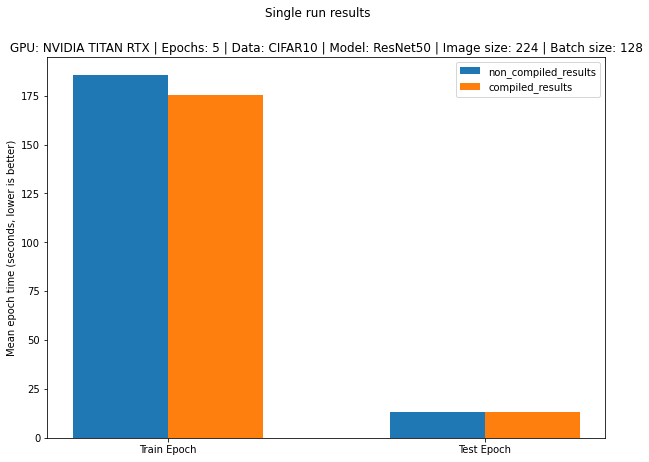

In [26]:
# 注：Create directory for saving figures
import os
dir_to_save_figures_in = "pytorch_2_results/figures/" 
os.makedirs(dir_to_save_figures_in, exist_ok=True)

# 注：Create a save path for the single run results
save_path_multi_run = f"{dir_to_save_figures_in}single_run_{GPU_NAME}_{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}_train_epoch_time.png"
print(f"[INFO] Save path for single run results: {save_path_multi_run}")

# 注：Plot the results and save the figures
plot_mean_epoch_times(non_compiled_results=single_run_no_compile_results_df, 
                      compiled_results=single_run_compile_results_df, 
                      multi_runs=False, 
                      save_path=save_path_multi_run, 
                      save=True)

这里发生了什么？

看起来在这次实验中，使用 `torch.compile()` 的模型反而比未使用时更慢（在 A100 上确实会出现这种情况；而在我本地的 NVIDIA TITAN RTX 上，编译模型略快）。

为什么会这样？

按 epoch 拆开看会发现：实验 2（开启 `torch.compile()`）在第一个 epoch 明显更慢，但从后续 epoch 开始逐渐快于实验 1（未开启）。

原因是 `torch.compile()` 在训练初期会做“预热”，并在后台执行一系列优化步骤。

这些 **前置优化步骤会消耗首轮时间**，但通常会让 **后续步骤更快**。

你可以把上面的训练轮数从 5 增加到 50 再测试，观察平均训练时间是否更能体现编译带来的收益。

### 3.4 保存单次运行结果（含 GPU 信息）

我们也可以把结果的原始数据导出到文件，把 dataframe 存为 CSV。

先创建用于保存结果的目录。

再为目标 dataframe 构建导出路径并写出。

In [27]:
# 注：Make a directory for single_run results
import os
pytorch_2_results_dir = "pytorch_2_results"
pytorch_2_single_run_results_dir = f"{pytorch_2_results_dir}/single_run_results"
os.makedirs(pytorch_2_single_run_results_dir, exist_ok=True)

# 注：Create filenames for each of the dataframes
save_name_for_non_compiled_results = f"single_run_non_compiled_results_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"
save_name_for_compiled_results = f"single_run_compiled_results_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"

# 注：Create filepaths to save the results to
single_run_no_compile_save_path = f"{pytorch_2_single_run_results_dir}/{save_name_for_non_compiled_results}"
single_run_compile_save_path = f"{pytorch_2_single_run_results_dir}/{save_name_for_compiled_results}"
print(f"[INFO] Saving non-compiled experiment 1 results to: {single_run_no_compile_save_path}")
print(f"[INFO] Saving compiled experiment 2 results to: {single_run_compile_save_path}")

# 注：Save the results
single_run_no_compile_results_df.to_csv(single_run_no_compile_save_path)
single_run_compile_results_df.to_csv(single_run_compile_save_path)

[INFO] Saving non-compiled experiment 1 results to: pytorch_2_results/single_run_results/single_run_non_compiled_results_CIFAR10_ResNet50_NVIDIA_TITAN_RTX.csv
[INFO] Saving compiled experiment 2 results to: pytorch_2_results/single_run_results/single_run_compiled_results_CIFAR10_ResNet50_NVIDIA_TITAN_RTX.csv


## 4. 多次运行模型计时

既然我们已经完成了单次运行下 `torch.compile()` 开关的对比，接下来就在多次运行场景下做同样测试。

我们先为实验 3 和实验 4 准备三个函数。

1. **实验 3：** `create_and_train_non_compiled_model()` - 这个函数与单次运行流程类似，把模型创建（通过 `create_model()`）和训练放在同一个函数中，便于重复调用并统计每次运行耗时。
2. **实验 4：** `create_compiled_model()` - 与上面的 `create_model()` 思路相近，但会先创建普通 PyTorch 模型，再调用 `torch.compile()` 并返回编译后的模型。
3. **实验 4：** `train_compiled_model()` - 接收已编译模型，按单次运行时同样的方式完成训练。

为什么实验 4 要把函数 2 和 3（`create_compiled_model()` 与 `train_compiled_model()`）拆开？

因为调用 `torch.compile()` 后，模型前几轮通常会经历“预热”，PyTorch 会在后台计算并缓存一批优化步骤。

因此在实践里，通常更推荐先 *一次性* 完成编译，再用已编译模型执行训练/推理。

In [28]:
def create_and_train_non_compiled_model(epochs=NUM_EPOCHS, 
                                        learning_rate=LEARNING_RATE, 
                                        disable_progress_bar=False):
    """
    Create and train a non-compiled PyTorch model.
    """
    model, _ = create_model()
    model.to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate)

    results = train(model=model,
                    train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    loss_fn=loss_fn,
                    optimizer=optimizer,
                    epochs=epochs,
                    device=device,
                    disable_progress_bar=disable_progress_bar)
    return results

def create_compiled_model():
    """
    Create a compiled PyTorch model and return it.
    """
    model, _ = create_model()
    model.to(device)
    
    compile_start_time = time.time()
    ### New in PyTorch 2.x ###
    compiled_model = torch.compile(model)
    ##########################
    compile_end_time = time.time()

    compile_time = compile_end_time - compile_start_time

    print(f"Time to compile: {compile_time} | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.")
    return compiled_model

def train_compiled_model(model=compiled_model, 
                         epochs=NUM_EPOCHS, 
                         learning_rate=LEARNING_RATE,
                         disable_progress_bar=False):
    """
    Train a compiled model and return the results.
    """
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(compiled_model.parameters(),
                                 lr=learning_rate)
    
    compile_results = train(model=model,
                            train_dataloader=train_dataloader,
                            test_dataloader=test_dataloader,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            epochs=epochs,
                            device=device,
                            disable_progress_bar=disable_progress_bar)
    
    return compile_results

### 4.1 实验 3：多次运行，不使用 compile

实验 3 和 4 的函数都准备好了！

先从实验 3 开始。

| **实验** | **模型** | **数据** | **Epochs** | **Batch size** | **Image size** | **`torch.compile()`** |  
|----- |-----| -----| -----| -----| -----| -----|
| 3（多次运行） | ResNet50 | CIFAR10 | 3x5 | 128 | 224 | 否 |

运行次数设为 3，epoch 设为 5。

我们会先创建一个空列表，用于保存每次运行结果，并在每次运行结束后追加进去。

> **注意：** 下面代码运行时长依赖你的 GPU 速度。我的实测是：Google Colab Pro 的 NVIDIA A100 约 20 分钟，本地 NVIDIA TITAN RTX 约 49 分钟。

In [29]:
# 注：Run non-compiled model for multiple runs
NUM_RUNS = 3
NUM_EPOCHS = 5

# 注：Create an empty list to store multiple run results
non_compile_results_multiple_runs = []

# 注：Run non-compiled model for multiple runs
for i in tqdm(range(NUM_RUNS)):
    print(f"[INFO] Run {i+1} of {NUM_RUNS} for non-compiled model")
    results = create_and_train_non_compiled_model(epochs=NUM_EPOCHS, disable_progress_bar=True)
    non_compile_results_multiple_runs.append(results)

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Run 1 of 3 for non-compiled model
Epoch: 1 | train_loss: 0.8242 | train_acc: 0.7136 | test_loss: 0.5486 | test_acc: 0.8124 | train_epoch_time: 185.1112 | test_epoch_time: 12.9925
Epoch: 2 | train_loss: 0.4415 | train_acc: 0.8479 | test_loss: 0.6415 | test_acc: 0.7829 | train_epoch_time: 185.0138 | test_epoch_time: 12.9690
Epoch: 3 | train_loss: 0.3229 | train_acc: 0.8882 | test_loss: 0.4486 | test_acc: 0.8488 | train_epoch_time: 185.0366 | test_epoch_time: 12.9433
Epoch: 4 | train_loss: 0.2433 | train_acc: 0.9151 | test_loss: 0.4376 | test_acc: 0.8596 | train_epoch_time: 185.0900 | test_epoch_time: 12.9465
Epoch: 5 | train_loss: 0.1785 | train_acc: 0.9379 | test_loss: 0.4305 | test_acc: 0.8641 | train_epoch_time: 185.0405 | test_epoch_time: 13.0102
[INFO] Run 2 of 3 for non-compiled model
Epoch: 1 | train_loss: 0.8304 | train_acc: 0.7101 | test_loss: 0.6132 | test_acc: 0.7884 | train_epoch_time: 185.0911 | test_epoch_time: 13.0429
Epoch: 2 | train_loss: 0.4602 | train_acc: 0.841

现在我们已经拿到实验 3 的结果列表，接下来遍历这些结果并构建一个包含全部结果的 dataframe。

随后按 epoch 编号（dataframe 的索引）分组求均值，得到 3 次运行的平均结果。

In [30]:
# 注：Go through non_compile_results_multiple_runs and create a dataframe for each run then concatenate them together
non_compile_results_dfs = []
for result in non_compile_results_multiple_runs:
    result_df = pd.DataFrame(result)
    non_compile_results_dfs.append(result_df)
non_compile_results_multiple_runs_df = pd.concat(non_compile_results_dfs)

# 注：Get the averages across the multiple runs
non_compile_results_multiple_runs_df = non_compile_results_multiple_runs_df.groupby(non_compile_results_multiple_runs_df.index).mean()
non_compile_results_multiple_runs_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,0.815352,0.716103,0.590690,0.796710,185.060622,13.017663
1,0.447013,0.845567,0.618526,0.790150,185.004740,12.973144
2,0.322255,0.888117,0.436471,0.852321,185.068499,12.956863
3,0.242587,0.915120,0.436207,0.858946,184.995601,12.969341
4,0.179439,0.937612,0.479547,0.854727,184.995575,12.993280


太好了！

这些结果稍后还会用到，先继续进入实验 4。

### 4.2 实验 4：多次运行，使用 compile

现在开始实验 4。

我们要在多次运行场景下使用已编译模型。

| **实验** | **模型** | **数据** | **Epochs** | **Batch size** | **Image size** | **`torch.compile()`** |  
|----- |-----| -----| -----| -----| -----| -----|
| 4（多次运行） | ResNet50 | CIFAR10 | 3x5 | 128 | 224 | 是 |

这里会用到前面写好的 `create_compiled_model()` 和 `train_compiled_model()`。

先创建 *已编译模型*，再进行 3 轮训练。

本节更关注耗时，而不是 loss/accuracy 本身。

之所以在开始只编译一次，是因为 PyTorch 的优化步骤只需要执行一次（这一步可能较慢），后续运行可复用这些优化结果。

我们也会像前面一样创建空列表，保存多轮运行结果。

> **注意：** 下面代码运行时长依赖你的 GPU 速度。我的实测是：Google Colab Pro 的 NVIDIA A100 约 18 分钟，本地 NVIDIA TITAN RTX 约 45 分钟。

In [31]:
# 注：Create compiled model
compiled_model = create_compiled_model()

# 注：Create an empty list to store compiled model results
compiled_results_multiple_runs = []

# 注：Run compiled model for multiple runs
for i in tqdm(range(NUM_RUNS)):
    print(f"[INFO] Run {i+1} of {NUM_RUNS} for compiled model")
    # 注：Train the compiled model (note: the model will only be compiled once and then re-used for subsequent runs)
    results = train_compiled_model(model=compiled_model, epochs=NUM_EPOCHS, disable_progress_bar=True)
    compiled_results_multiple_runs.append(results)

Time to compile: 0.001275777816772461 | Note: The first time you compile your model, the first few epochs will be slower than subsequent runs.


  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Run 1 of 3 for compiled model
Epoch: 1 | train_loss: 0.8026 | train_acc: 0.7192 | test_loss: 0.6995 | test_acc: 0.7650 | train_epoch_time: 194.3336 | test_epoch_time: 20.6106
Epoch: 2 | train_loss: 0.4440 | train_acc: 0.8483 | test_loss: 0.5565 | test_acc: 0.8089 | train_epoch_time: 169.3882 | test_epoch_time: 10.8076
Epoch: 3 | train_loss: 0.3208 | train_acc: 0.8896 | test_loss: 0.4164 | test_acc: 0.8620 | train_epoch_time: 169.9283 | test_epoch_time: 10.8361
Epoch: 4 | train_loss: 0.2329 | train_acc: 0.9197 | test_loss: 0.3635 | test_acc: 0.8792 | train_epoch_time: 169.8744 | test_epoch_time: 10.9050
Epoch: 5 | train_loss: 0.1803 | train_acc: 0.9369 | test_loss: 0.4387 | test_acc: 0.8587 | train_epoch_time: 169.6391 | test_epoch_time: 10.8240
[INFO] Run 2 of 3 for compiled model
Epoch: 1 | train_loss: 0.1875 | train_acc: 0.9347 | test_loss: 0.4187 | test_acc: 0.8714 | train_epoch_time: 169.4814 | test_epoch_time: 10.8180
Epoch: 2 | train_loss: 0.1288 | train_acc: 0.9550 | test

实验 4 完成！

下面把结果合并成 dataframe，并对各次运行按 epoch（即 dataframe 索引）分组求均值。

In [32]:
# 注：Go through compile_results_multiple_runs and create a dataframe for each run then concatenate them together
compile_results_dfs = []
for result in compiled_results_multiple_runs:
    result_df = pd.DataFrame(result)
    compile_results_dfs.append(result_df)
compile_results_multiple_runs_df = pd.concat(compile_results_dfs)

# 注：Get the averages across the multiple runs
compile_results_multiple_runs_df = compile_results_multiple_runs_df.groupby(compile_results_multiple_runs_df.index).mean() # .index = groupby the epoch number
compile_results_multiple_runs_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,0.353548,0.876332,0.517181,0.840124,177.766548,14.111428
1,0.210781,0.927845,0.474630,0.856375,169.481367,10.838063
2,0.152098,0.947577,0.450293,0.872396,169.703638,10.833619
3,0.121230,0.958177,0.424376,0.884065,169.707751,10.904810
4,0.092080,0.968116,0.481520,0.870649,169.608708,10.854486


### 4.3 对比实验 3 与实验 4 结果

多次运行实验完成！

现在来检查结果。

我们继续使用前面创建的 `plot_mean_epoch_times()` 函数。

这次把 `multi_runs` 参数设为 `True`，让图表正确反映“多次运行平均结果”。

同时也确认好图像保存目录。

Mean train epoch time difference: -7.443% (negative means faster)
Mean test epoch time difference: -11.351% (negative means faster)
[INFO] Plot saved to pytorch_2_results/figures/multi_run_NVIDIA_TITAN_RTX_ResNet50_CIFAR10_224_train_epoch_time.png


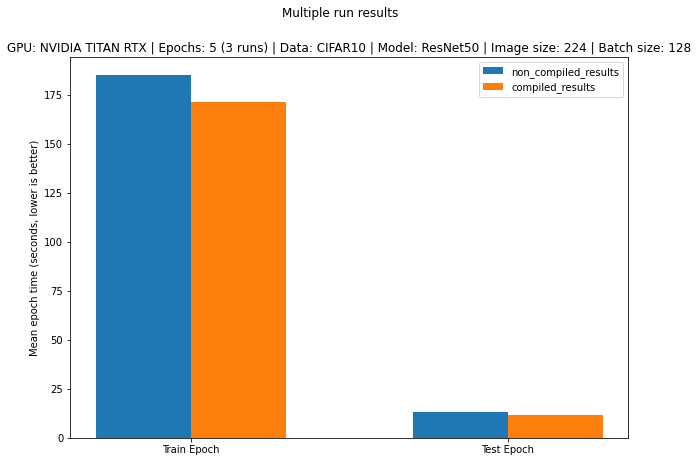

In [33]:
# 注：Create a directory to save the multi-run figure to 
os.makedirs("pytorch_2_results/figures", exist_ok=True)

# 注：Create a path to save the figure for multiple runs
save_path_multi_run = f"pytorch_2_results/figures/multi_run_{GPU_NAME}_{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}_train_epoch_time.png"

# 注：Plot the mean epoch times for experiment 3 and 4
plot_mean_epoch_times(non_compiled_results=non_compile_results_multiple_runs_df, 
                      compiled_results=compile_results_multiple_runs_df, 
                      multi_runs=True, 
                      num_runs=NUM_RUNS, 
                      save_path=save_path_multi_run, 
                      save=True)

很好！

从结果看，编译模型在多次运行下整体略优于未编译模型。

这很可能是因为在单次运行（且 epoch 较少）时，模型编译会让第一个 epoch 花费较多时间。

但当模型已编译并进行更长训练后，后台优化带来的提速会逐渐体现。

一个自然扩展是把训练时长拉长，比如 100 个 epochs，再比较两者差异。

### 4.4 保存多次运行结果（含 GPU 信息）

同样把实验 3 与实验 4 的结果 dataframe 导出到文件，便于后续复查或与其他模型做对比。

In [34]:
# 注：Make a directory for multi_run results
import os
pytorch_2_results_dir = "pytorch_2_results"
pytorch_2_multi_run_results_dir = f"{pytorch_2_results_dir}/multi_run_results"
os.makedirs(pytorch_2_multi_run_results_dir, exist_ok=True)

# 注：Create filenames for each of the dataframes
save_name_for_multi_run_non_compiled_results = f"multi_run_non_compiled_results_{NUM_RUNS}_runs_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"
save_name_for_multi_run_compiled_results = f"multi_run_compiled_results_{NUM_RUNS}_runs_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"

# 注：Create filepaths to save the results to
multi_run_no_compile_save_path = f"{pytorch_2_multi_run_results_dir}/{save_name_for_non_compiled_results}"
multi_run_compile_save_path = f"{pytorch_2_multi_run_results_dir}/{save_name_for_compiled_results}"
print(f"[INFO] Saving experiment 3 non-compiled results to: {multi_run_no_compile_save_path}")
print(f"[INFO] Saving experiment 4 compiled results to: {multi_run_compile_save_path}")

# 注：Save the results
non_compile_results_multiple_runs_df.to_csv(multi_run_no_compile_save_path)
compile_results_multiple_runs_df.to_csv(multi_run_compile_save_path)

[INFO] Saving experiment 3 non-compiled results to: pytorch_2_results/multi_run_results/single_run_non_compiled_results_CIFAR10_ResNet50_NVIDIA_TITAN_RTX.csv
[INFO] Saving experiment 4 compiled results to: pytorch_2_results/multi_run_results/single_run_compiled_results_CIFAR10_ResNet50_NVIDIA_TITAN_RTX.csv


## 5. 可进一步改进与扩展的方向

我们已经覆盖了 `torch.compile()` 的核心概念，并完成了多组对比实验代码。

但还能继续深入。

如前面所述，PyTorch 2.0 与 `torch.compile()` 的很多提速，来自两点：更新的 GPU（如 A100 及以上）以及尽可能高的 GPU 利用率（更大 batch、更大模型）。

如果想继续提高速度，建议进一步研究/尝试：

* **更强的 CPU** - 我有个猜测：Google Colab 实例可能受限于 2 个 CPU 核心；如果 CPU 更多，提速数据可能还会提高。可用 [PyTorch Profiler](https://pytorch.org/tutorials/recipes/recipes/profiler_recipe.html)（定位各流程耗时）验证这一点。
* **混合精度训练** - 新 GPU 能处理多种精度（如 [`torch.float16`](https://pytorch.org/docs/stable/tensors.html#data-types) 与 [`torch.bfloat16`](https://pytorch.org/docs/stable/generated/torch.Tensor.bfloat16.html)），可进一步提升训练/推理速度。我预计混合精度会带来比本教程更明显的提速。可参考 PyTorch 自动混合精度（AMP）文档：[automatic mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html#amp-examples)。
* **Transformer 模型的*相对*提速可能高于卷积模型** - PyTorch 2.0 提供了 [accelerated transformer models 稳定支持](https://pytorch.org/blog/pytorch-2.0-release/#stable-accelerated-pytorch-2-transformers)。核心提速点之一是 [`scaled_dot_product_attention()`](https://pytorch.org/docs/master/generated/torch.nn.functional.scaled_dot_product_attention.html?highlight=scaled_dot_product#torch.nn.functional.scaled_dot_product_attention) 的改进实现，会按硬件自动选择最优 attention 版本。更多细节可看 [官方教程](https://pytorch.org/tutorials/intermediate/scaled_dot_product_attention_tutorial.html)。
* **训练更久** - 正如前文所说，`torch.compile()` 的提速通常在更长训练中更明显。可以把 epoch 数拉长，并换用不同数据集/模型（如 transformer）进行对比。

## 6. 延伸学习资源

下面这些资源对理解 PyTorch 2.0 及其新特性非常有帮助。

* [PyTorch 2.0 launch blog post](https://pytorch.org/get-started/pytorch-2.0/)。
* [PyTorch 2.0 release notes](https://pytorch.org/blog/pytorch-2.0-release/)（博客版）。
    * 以及 [GitHub release notes](https://github.com/pytorch/pytorch/releases/tag/v2.0.0)（细节非常多）。
* [PyTorch default device context manager docs](https://github.com/pytorch/tutorials/pull/2220/files)。
* [PyTorch 2.0 video introduction on YouTube](https://youtu.be/WqLKfta5Ijw)（作者本人录制）。
* 参考 [Sebastian Raschka 的这条建议](https://twitter.com/rasbt/status/1638297626385719297?s=20)：在正式训练前先跑一个示例 batch 完成 warm-up，可提升 `torch.compile()` 后续训练速度（这也解释了多次运行时的加速更明显）。